In [55]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [56]:
df=pd.read_csv("/content/FraudTest T2.csv")

In [57]:
df.shape

(555719, 23)

In [58]:
df.size

12781537

In [59]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,6/21/2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,3/19/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,6/21/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1/17/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,6/21/2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",10/21/1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,6/21/2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,7/25/1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,6/21/2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,7/6/1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [60]:
df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
555714,555714,12/31/2020 23:59,3.056060e+13,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.4931,-91.8912,519,Town planner,2/13/1966,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,12/31/2020 23:59,3.556610e+15,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,12/27/1999,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,12/31/2020 23:59,6.011720e+15,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,11/29/1981,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,12/31/2020 23:59,4.079770e+12,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.6255,-116.4493,129,Cartographer,12/15/1965,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0
555718,555718,12/31/2020 23:59,4.170690e+15,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,Edmond,OK,73034,35.6665,-97.4798,116001,Media buyer,5/10/1993,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [62]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800430e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521420e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635330e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992350e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [63]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [64]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [65]:
df.dropna(inplace=True)

In [66]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [67]:
x=df.drop("is_fraud",axis=1)
# Drop non-numeric columns that cannot be directly used by LogisticRegression
non_numeric_cols = [
    'trans_date_trans_time', 'merchant', 'category', 'first', 'last',
    'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'
]
x = x.drop(columns=non_numeric_cols, errors='ignore')
y=df["is_fraud"]

In [68]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=42,test_size=0.2)
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(444575, 10)
(444575,)
(111144, 10)
(111144,)


In [69]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

print("Features scaled successfully!")

Features scaled successfully!


In [70]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
Xt_scaled, Yt_scaled = sm.fit_resample(xtrain_scaled, ytrain)

print(f"Shape of training data after SMOTE and Scaling: {Xt_scaled.shape}")
print(f"Distribution of target variable after SMOTE and Scaling:\n{Yt_scaled.value_counts()}")

Shape of training data after SMOTE and Scaling: (885712, 10)
Distribution of target variable after SMOTE and Scaling:
is_fraud
0    442856
1    442856
Name: count, dtype: int64


In [71]:
model_smote_scaled = LogisticRegression(solver='liblinear', random_state=42)
model_smote_scaled.fit(Xt_scaled, Yt_scaled)

y_pred_smote_scaled = model_smote_scaled.predict(xtest_scaled)

print("\nModel Evaluation after SMOTE and Scaling:")
print(f"Accuracy: {accuracy_score(ytest, y_pred_smote_scaled):.4f}")
print(f"Precision: {precision_score(ytest, y_pred_smote_scaled):.4f}")
print(f"Recall: {recall_score(ytest, y_pred_smote_scaled):.4f}")
print(f"F1-Score: {f1_score(ytest, y_pred_smote_scaled):.4f}")


Model Evaluation after SMOTE and Scaling:
Accuracy: 0.9428
Precision: 0.0503
Recall: 0.7793
F1-Score: 0.0946


## Experimenting with Decision Tree Classifier

In [77]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(xtrain, ytrain)

DecisionTreeClassifier(random_state=42)

In [73]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xt_scaled, Yt_scaled)

y_pred_dt = dt_model.predict(xtest_scaled)

print("\nDecision Tree Model Evaluation (after SMOTE and Scaling):")
print(f"Accuracy: {accuracy_score(ytest, y_pred_dt):.4f}")
print(f"Precision: {precision_score(ytest, y_pred_dt):.4f}")
print(f"Recall: {recall_score(ytest, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(ytest, y_pred_dt):.4f}")


Decision Tree Model Evaluation (after SMOTE and Scaling):
Accuracy: 0.9931
Precision: 0.3084
Recall: 0.6479
F1-Score: 0.4179


In [74]:
model=LogisticRegression()
model.fit(xtrain,ytrain)

LogisticRegression()

In [75]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,553574
1,2145


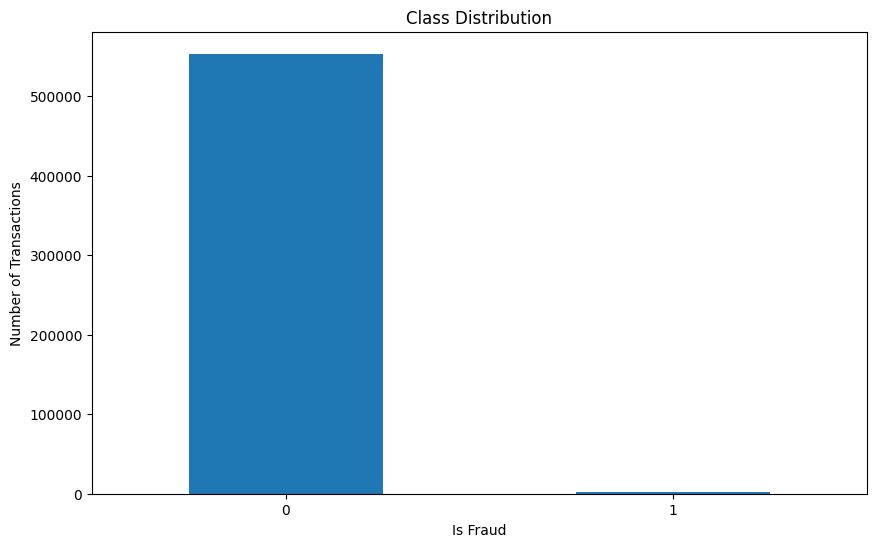

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Is Fraud')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()